# EDA — Fraud_Data.csv (E-commerce Transactions)

**Goal:** Understand the structure, distributions, and fraud patterns in the e-commerce dataset.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

DATA_PATH = 'data/raw/Fraud_Data.csv'

## 1. Load Data

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head()

Shape: (151112, 11)


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   user_id         151112 non-null  int64  
 1   signup_time     151112 non-null  object 
 2   purchase_time   151112 non-null  object 
 3   purchase_value  151112 non-null  int64  
 4   device_id       151112 non-null  object 
 5   source          151112 non-null  object 
 6   browser         151112 non-null  object 
 7   sex             151112 non-null  object 
 8   age             151112 non-null  int64  
 9   ip_address      151112 non-null  float64
 10  class           151112 non-null  int64  
dtypes: float64(1), int64(4), object(6)
memory usage: 12.7+ MB


In [4]:
df.describe()

,user_id,purchase_value,age,ip_address,class
count,151112.000000,151112.000000,151112.000000,1.511120e+05,151112.000000
mean,200171.040970,36.935372,33.140704,2.152145e+09,0.093646
std,115369.285024,18.322762,8.617733,1.248497e+09,0.291336
min,2.000000,9.000000,18.000000,5.209350e+04,0.000000
25%,100642.500000,22.000000,27.000000,1.085934e+09,0.000000
50%,199958.000000,35.000000,33.000000,2.154770e+09,0.000000
75%,300054.000000,49.000000,39.000000,3.243258e+09,0.000000
max,400000.000000,154.000000,76.000000,4.294850e+09,1.000000


## 2. Data Cleaning

In [5]:
# Missing values
print('Missing values:')
print(df.isnull().sum())

# Duplicates
print(f'\nDuplicate rows: {df.duplicated().sum()}')
df.drop_duplicates(inplace=True)

# Fix datetime columns
df['signup_time'] = pd.to_datetime(df['signup_time'])
df['purchase_time'] = pd.to_datetime(df['purchase_time'])
print('\nData types after fix:')
print(df.dtypes)

Missing values:
user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64

Duplicate rows: 0

Data types after fix:
user_id                    int64
signup_time       datetime64[ns]
purchase_time     datetime64[ns]
purchase_value             int64
device_id                 object
source                    object
browser                   object
sex                       object
age                        int64
ip_address               float64
class                      int64
dtype: object


## 3. Class Imbalance

Class distribution:
        count  percent
class                 
0      136961    90.64
1       14151     9.36


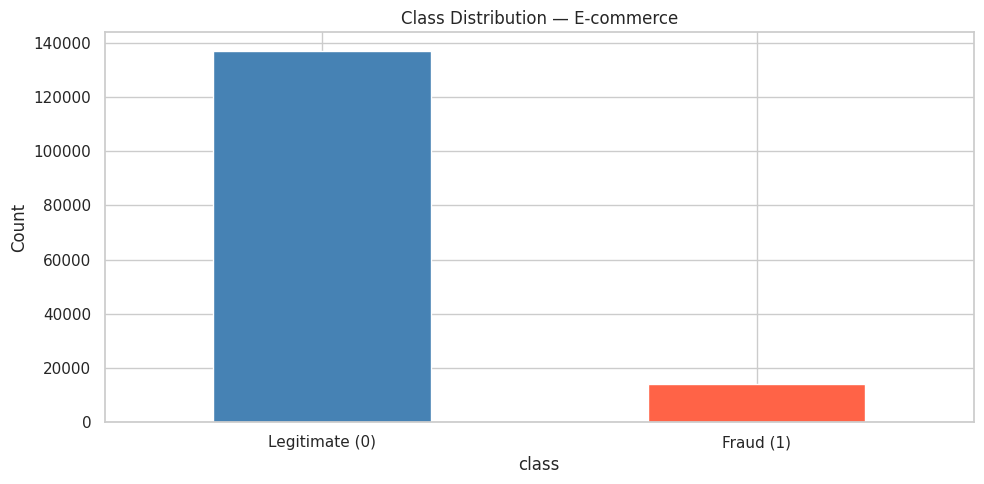

In [6]:
class_counts = df['class'].value_counts()
class_pct = df['class'].value_counts(normalize=True) * 100

print('Class distribution:')
print(pd.DataFrame({'count': class_counts, 'percent': class_pct.round(2)}))

fig, ax = plt.subplots()
class_counts.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'])
ax.set_xticklabels(['Legitimate (0)', 'Fraud (1)'], rotation=0)
ax.set_title('Class Distribution — E-commerce')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('data/processed/class_dist_fraud.png', dpi=150)
plt.show()

## 4. Univariate Analysis

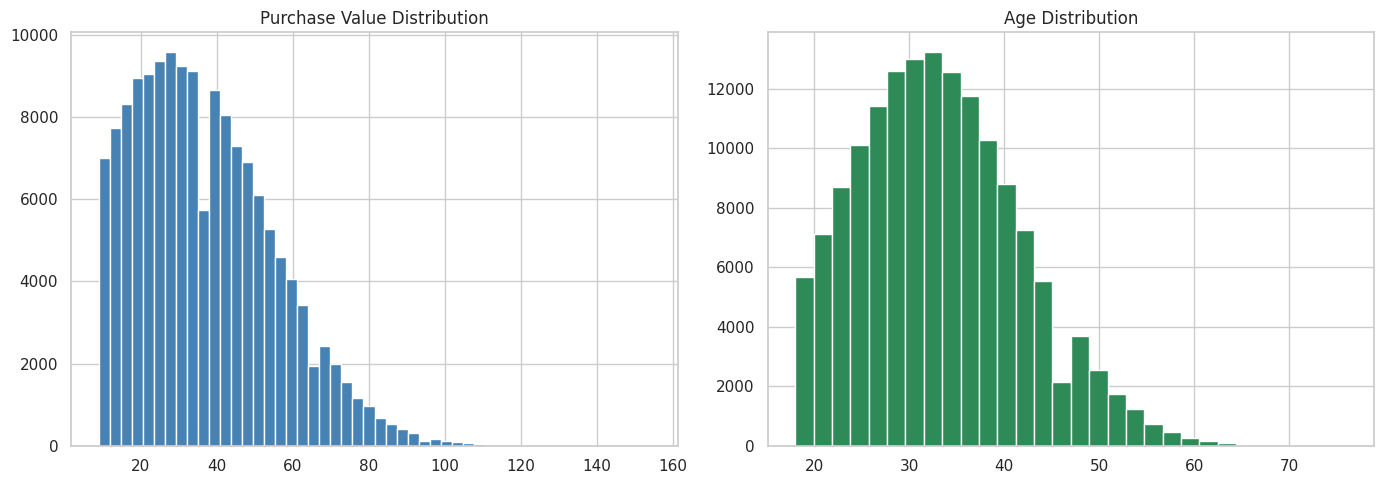

In [7]:
# Purchase value distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df['purchase_value'].hist(bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Purchase Value Distribution')
df['age'].hist(bins=30, ax=axes[1], color='seagreen')
axes[1].set_title('Age Distribution')
plt.tight_layout()
plt.show()

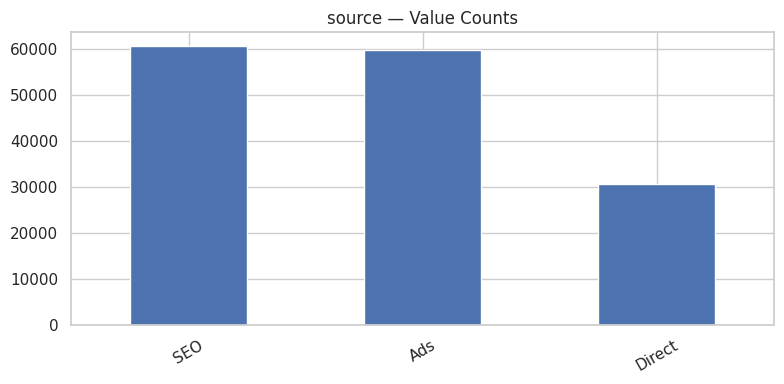

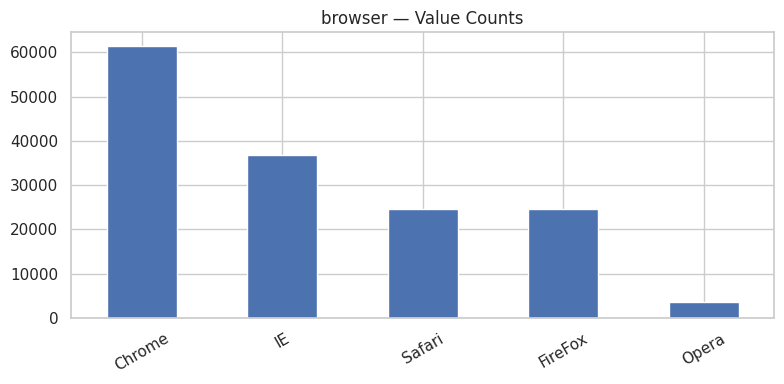

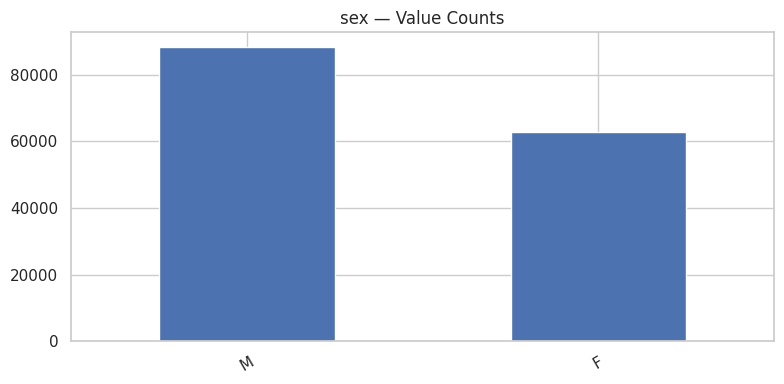

In [8]:
# Categorical feature counts
for col in ['source', 'browser', 'sex']:
    fig, ax = plt.subplots(figsize=(8, 4))
    df[col].value_counts().plot(kind='bar', ax=ax)
    ax.set_title(f'{col} — Value Counts')
    ax.set_xlabel('')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

## 5. Bivariate Analysis (Feature vs Fraud)

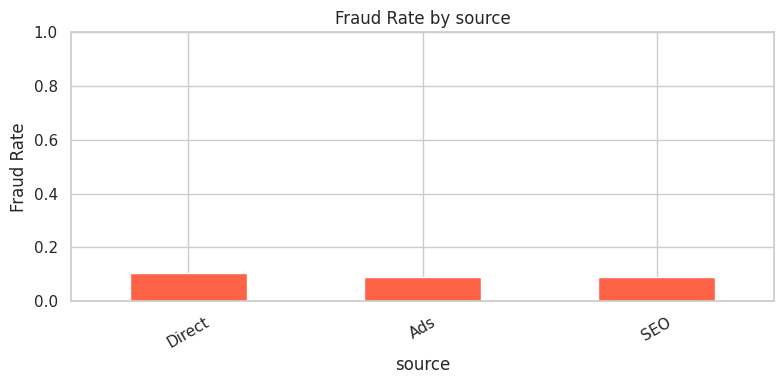

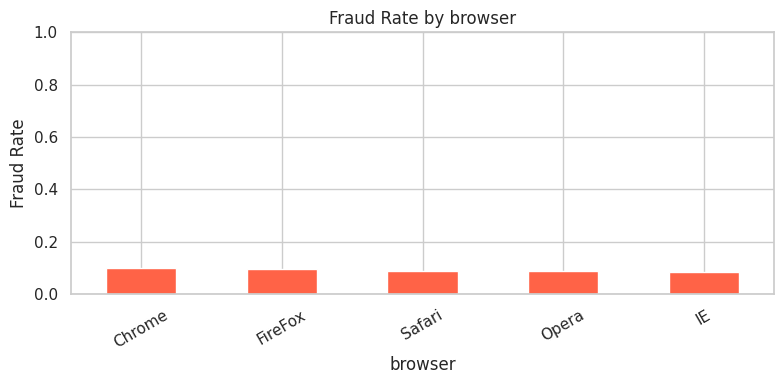

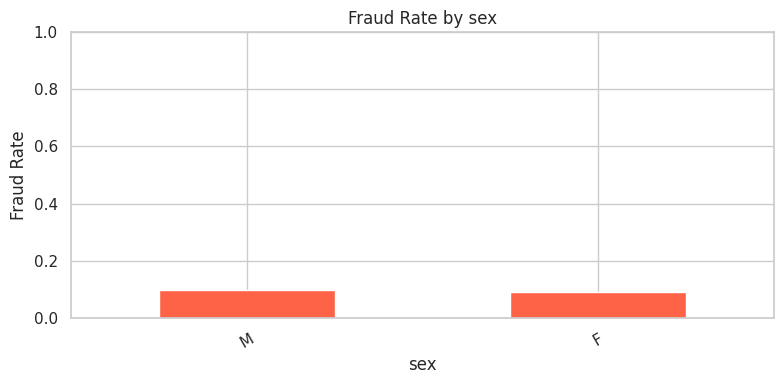

In [9]:
# Fraud rate by source
for col in ['source', 'browser', 'sex']:
    fraud_rate = df.groupby(col)['class'].mean().sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(8, 4))
    fraud_rate.plot(kind='bar', ax=ax, color='tomato')
    ax.set_title(f'Fraud Rate by {col}')
    ax.set_ylabel('Fraud Rate')
    ax.set_ylim(0, 1)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

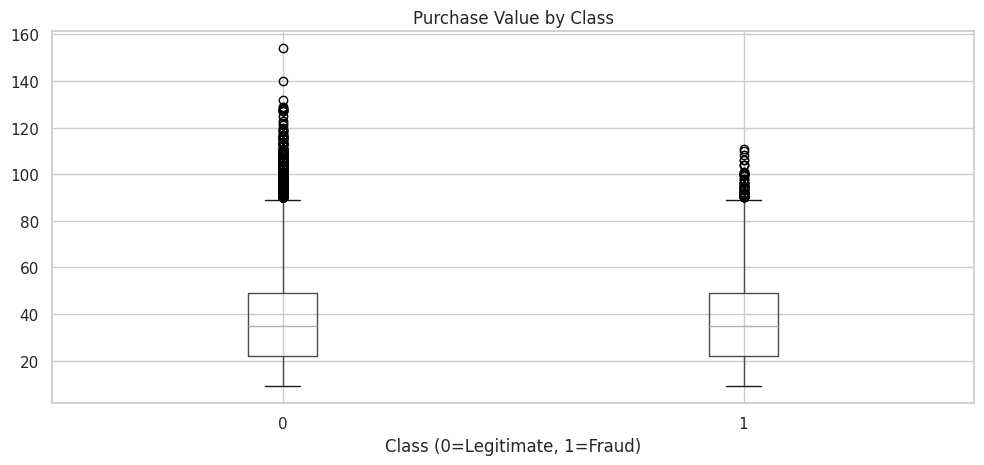

In [10]:
# Purchase value: fraud vs legitimate
fig, ax = plt.subplots(figsize=(10, 5))
df.boxplot(column='purchase_value', by='class', ax=ax)
ax.set_title('Purchase Value by Class')
ax.set_xlabel('Class (0=Legitimate, 1=Fraud)')
plt.suptitle('')
plt.tight_layout()
plt.show()

## 6. Save Cleaned Data

In [11]:
df.to_csv('data/processed/fraud_data_cleaned.csv', index=False)
print('Saved to data/processed/fraud_data_cleaned.csv')

Saved to data/processed/fraud_data_cleaned.csv
